In [2]:
# Cell 1: Import required libraries and load the Excel dataset

import pandas as pd
import numpy as np

# For visualisation later
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# header=2 is used because the actual column names start from the 3rd row in the Excel file
file_path = "Dataset for People for their Blood Glucose Level with their Superficial body feature readings..xlsx"

df = pd.read_excel(file_path, header=2)

# Display first few rows
print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully
Shape: (16969, 10)


,Age,Blood Glucose Level(BGL),Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9,79,73,118,98,98.300707,99,0,0,N
1,9,80,73,119,102,98.300707,94,1,0,N
2,9,70,76,110,81,98.300707,98,1,0,N
3,9,70,78,115,96,98.300707,96,1,0,N
4,66,100,96,144,92,97.807052,98,0,0,N


In [3]:
# Cell 2: Clean column names for easier coding

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("/", "_")
)

# Rename columns clearly
df = df.rename(columns={
    "blood_glucose_levelbgl": "blood_glucose_level",
    "diastolic_blood_pressure": "diastolic_blood_pressure",
    "systolic_blood_pressure": "systolic_blood_pressure",
    "heart_rate": "heart_rate",
    "body_temperature": "body_temperature",
    "spo2": "spo2",
    "sweating__y_n": "sweating_y_n",
    "shivering_y_n": "shivering_y_n",
    "diabetic_nondiabetic_d_n": "diabetic_status"
})

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['age', 'blood_glucose_level', 'diastolic_blood_pressure', 'systolic_blood_pressure', 'heart_rate', 'body_temperature', 'spo2', 'sweating_y_n', 'shivering_y_n', 'diabetic_status']


In [4]:
# Cell 3: Check dataset structure, missing values, and duplicate records

print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Dataset shape: (16969, 10)

Data types:
age                           int64
blood_glucose_level           int64
diastolic_blood_pressure      int64
systolic_blood_pressure       int64
heart_rate                    int64
body_temperature            float64
spo2                          int64
sweating_y_n                  int64
shivering_y_n                 int64
diabetic_status              object
dtype: object

Missing values in each column:
age                         0
blood_glucose_level         0
diastolic_blood_pressure    0
systolic_blood_pressure     0
heart_rate                  0
body_temperature            0
spo2                        0
sweating_y_n                0
shivering_y_n               0
diabetic_status             0
dtype: int64

Number of duplicate rows:
257


In [5]:
# Cell 4: Remove duplicate rows and handle missing values

# Remove exact duplicate rows
df = df.drop_duplicates()

# Drop rows with missing values
# This is suitable here because the dataset has important medical/sensor readings
df = df.dropna()

print("Shape after removing duplicates and missing values:", df.shape)

print("\nRemaining missing values:")
print(df.isnull().sum())

Shape after removing duplicates and missing values: (16712, 10)

Remaining missing values:
age                         0
blood_glucose_level         0
diastolic_blood_pressure    0
systolic_blood_pressure     0
heart_rate                  0
body_temperature            0
spo2                        0
sweating_y_n                0
shivering_y_n               0
diabetic_status             0
dtype: int64


In [6]:
# Cell 5: Convert numerical columns to proper numeric format

numeric_columns = [
    "age",
    "blood_glucose_level",
    "diastolic_blood_pressure",
    "systolic_blood_pressure",
    "heart_rate",
    "body_temperature",
    "spo2"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert sweating and shivering into integer format
df["sweating_y_n"] = df["sweating_y_n"].astype(int)
df["shivering_y_n"] = df["shivering_y_n"].astype(int)

print("Updated data types:")
print(df.dtypes)

Updated data types:
age                           int64
blood_glucose_level           int64
diastolic_blood_pressure      int64
systolic_blood_pressure       int64
heart_rate                    int64
body_temperature            float64
spo2                          int64
sweating_y_n                  int64
shivering_y_n                 int64
diabetic_status              object
dtype: object


In [7]:
# Cell 6: Create the target column for classification

# Target definition:
# 1 = Hypoglycemia
# 0 = Normal / Not hypoglycemia

df["hypoglycemia_status"] = np.where(df["blood_glucose_level"] < 70, 1, 0)

# Keep target column at the end
target_col = df.pop("hypoglycemia_status")
df["hypoglycemia_status"] = target_col

print("Target column created successfully")
print(df["hypoglycemia_status"].value_counts())

print("\nTarget distribution percentage:")
print(df["hypoglycemia_status"].value_counts(normalize=True) * 100)

Target column created successfully
hypoglycemia_status
0    11565
1     5147
Name: count, dtype: int64

Target distribution percentage:
hypoglycemia_status
0    69.201771
1    30.798229
Name: proportion, dtype: float64


In [8]:
# Cell 7: Encode diabetic_status column

# D = Diabetic
# N = Non-diabetic

df["diabetic_status"] = df["diabetic_status"].astype(str).str.strip().str.upper()

df["diabetic_status"] = df["diabetic_status"].map({
    "D": 1,
    "N": 0
})

print("Diabetic status encoded:")
print(df["diabetic_status"].value_counts())

print("\nDataset after encoding:")
display(df.head())

Diabetic status encoded:
diabetic_status
1    16384
0      328
Name: count, dtype: int64

Dataset after encoding:


,age,blood_glucose_level,diastolic_blood_pressure,systolic_blood_pressure,heart_rate,body_temperature,spo2,sweating_y_n,shivering_y_n,diabetic_status,hypoglycemia_status
0,9,79,73,118,98,98.300707,99,0,0,0,0
1,9,80,73,119,102,98.300707,94,1,0,0,0
2,9,70,76,110,81,98.300707,98,1,0,0,0
3,9,70,78,115,96,98.300707,96,1,0,0,0
4,66,100,96,144,92,97.807052,98,0,0,0,0


In [9]:
# Cell 8: Prepare final cleaned dataset for machine learning

# IMPORTANT:
# blood_glucose_level is used to create the target.
# Therefore, it should be removed from input features to avoid data leakage.

model_df = df.drop(columns=["blood_glucose_level"])

# Separate input features and target column
X = model_df.drop(columns=["hypoglycemia_status"])
y = model_df["hypoglycemia_status"]

print("Final cleaned dataset shape:", model_df.shape)
print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFinal columns used for modelling:")
print(model_df.columns.tolist())

display(model_df.head())

Final cleaned dataset shape: (16712, 10)
Input feature shape: (16712, 9)
Target shape: (16712,)

Final columns used for modelling:
['age', 'diastolic_blood_pressure', 'systolic_blood_pressure', 'heart_rate', 'body_temperature', 'spo2', 'sweating_y_n', 'shivering_y_n', 'diabetic_status', 'hypoglycemia_status']


,age,diastolic_blood_pressure,systolic_blood_pressure,heart_rate,body_temperature,spo2,sweating_y_n,shivering_y_n,diabetic_status,hypoglycemia_status
0,9,73,118,98,98.300707,99,0,0,0,0
1,9,73,119,102,98.300707,94,1,0,0,0
2,9,76,110,81,98.300707,98,1,0,0,0
3,9,78,115,96,98.300707,96,1,0,0,0
4,66,96,144,92,97.807052,98,0,0,0,0


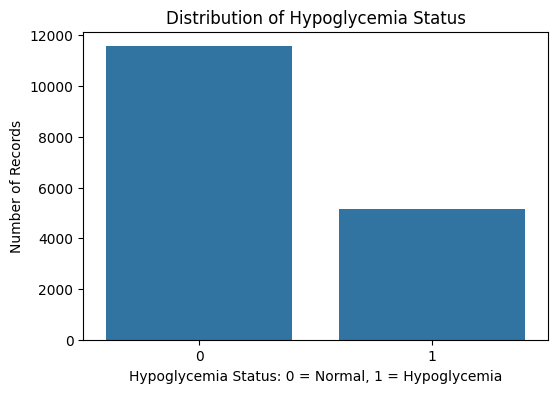

hypoglycemia_status
0    11565
1     5147
Name: count, dtype: int64


In [10]:
# EDA Plot 1: Distribution of hypoglycemia target classes

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="hypoglycemia_status"
)

plt.title("Distribution of Hypoglycemia Status")
plt.xlabel("Hypoglycemia Status: 0 = Normal, 1 = Hypoglycemia")
plt.ylabel("Number of Records")

plt.show()

print(df["hypoglycemia_status"].value_counts())

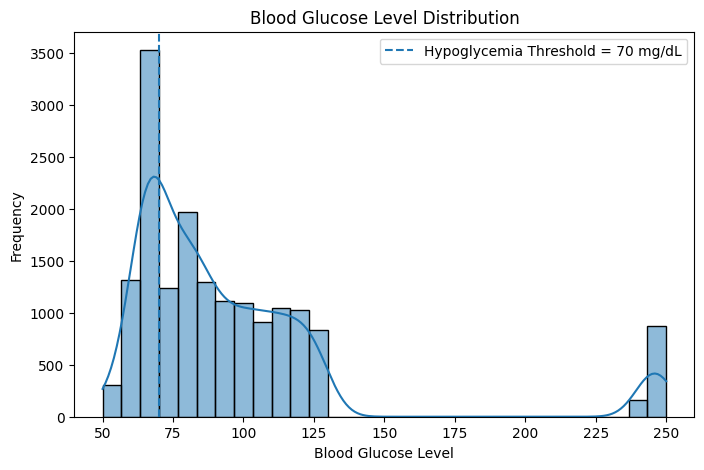

In [11]:
# EDA Plot 2: Distribution of blood glucose level

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="blood_glucose_level",
    bins=30,
    kde=True
)

# Threshold line for hypoglycemia
plt.axvline(70, linestyle="--", label="Hypoglycemia Threshold = 70 mg/dL")

plt.title("Blood Glucose Level Distribution")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Frequency")
plt.legend()

plt.show()

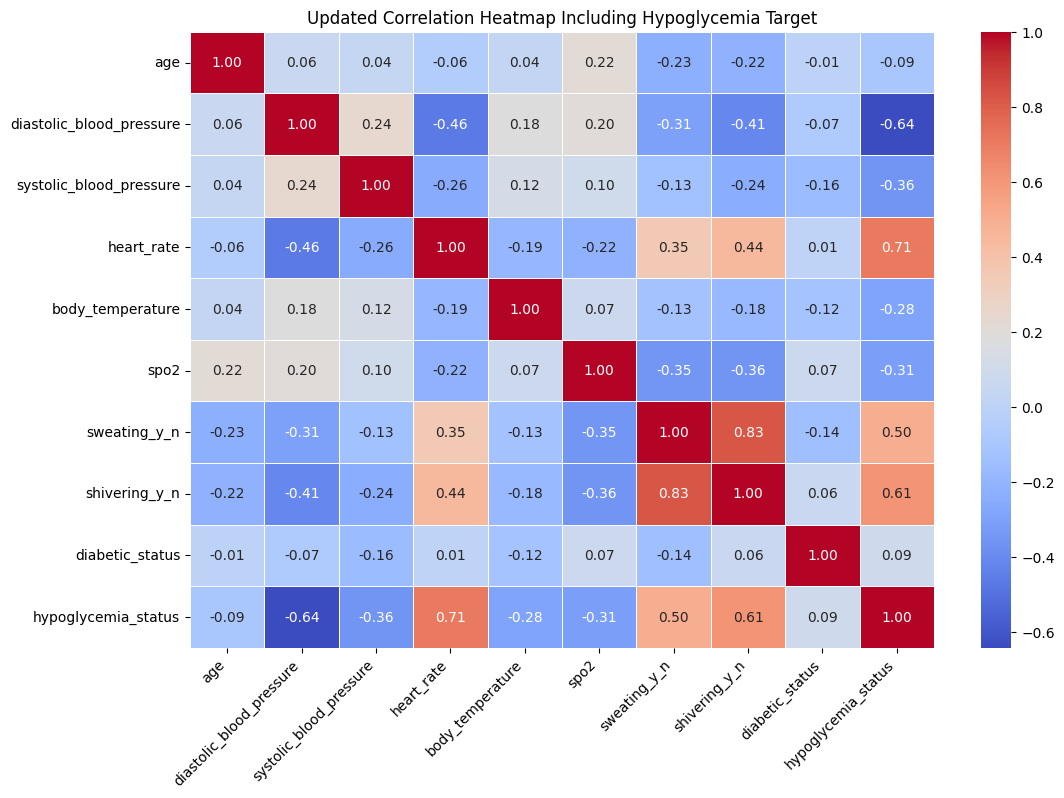

In [12]:
# EDA Plot 3: Correlation heatmap including hypoglycemia target

# Blood glucose level is removed from this heatmap because it directly defines the target.
# This avoids showing an artificial direct relationship.

heatmap_df = df.drop(columns=["blood_glucose_level"])

corr_matrix = heatmap_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Updated Correlation Heatmap Including Hypoglycemia Target")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

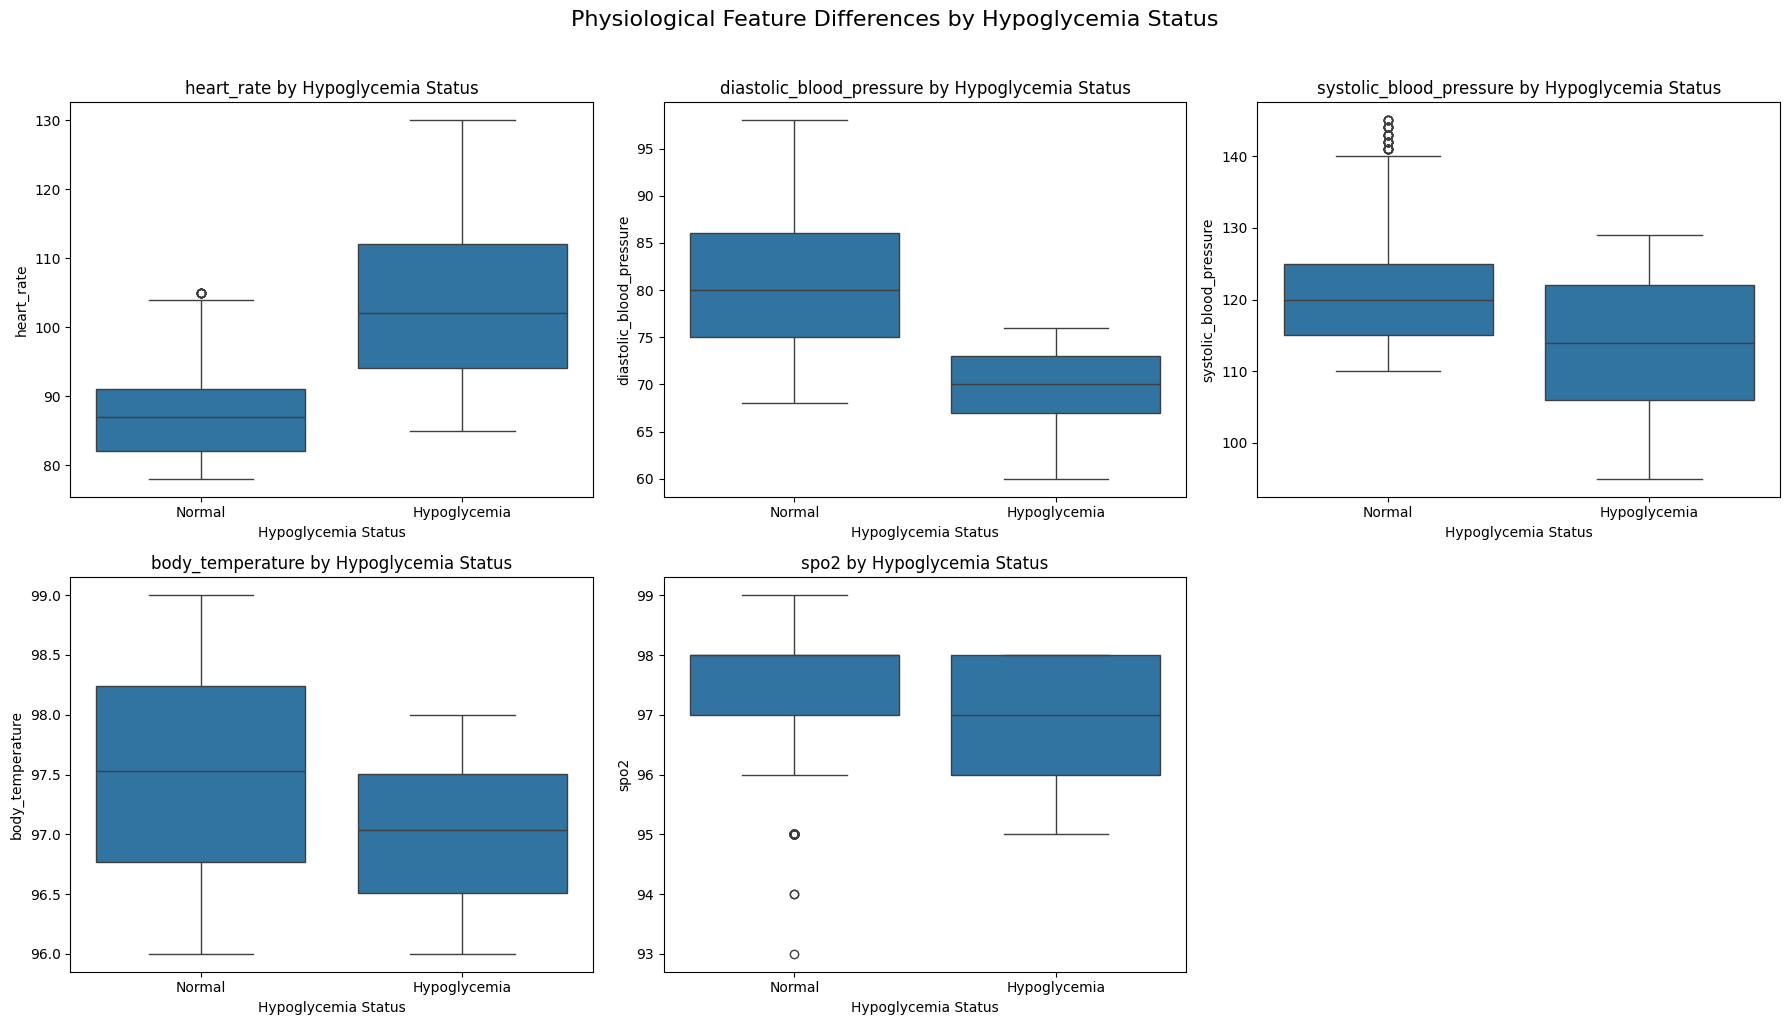

In [13]:
# EDA Plot 4: Physiological feature differences by hypoglycemia status
# This version creates separate boxplots so that all features are clearly visible.
# It avoids the problem of small-range features like body_temperature and spo2 being compressed.

selected_features = [
    "heart_rate",
    "diastolic_blood_pressure",
    "systolic_blood_pressure",
    "body_temperature",
    "spo2"
]

# Create a copy for plotting
plot_df = df.copy()

# Convert target values into readable labels
plot_df["hypoglycemia_label"] = plot_df["hypoglycemia_status"].map({
    0: "Normal",
    1: "Hypoglycemia"
})

# Create subplot layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten axes for easy looping
axes = axes.flatten()

# Plot each physiological feature separately
for i, feature in enumerate(selected_features):
    sns.boxplot(
        data=plot_df,
        x="hypoglycemia_label",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} by Hypoglycemia Status", fontsize=12)
    axes[i].set_xlabel("Hypoglycemia Status")
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis="x", rotation=0)

# Remove the empty 6th subplot because only 5 features are used
fig.delaxes(axes[-1])

# Main title
fig.suptitle(
    "Physiological Feature Differences by Hypoglycemia Status",
    fontsize=16,
    y=1.02
)

# Adjust layout so all plots, titles, and labels are visible
plt.tight_layout()

plt.show()

In [14]:
# Cell 9: Train-test split

from sklearn.model_selection import train_test_split

# Target column
target_column = "hypoglycemia_status"

# Input features
# blood_glucose_level is removed because it was used to create the target.
# Keeping it would cause data leakage.
X = model_df.drop(columns=[target_column])
y = model_df[target_column]

# Split dataset into training and testing sets
# stratify=y keeps the same target class distribution in train and test data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-test split completed")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Train-test split completed
X_train shape: (13369, 9)
X_test shape: (3343, 9)
y_train shape: (13369,)
y_test shape: (3343,)

Training target distribution:
hypoglycemia_status
0    9252
1    4117
Name: count, dtype: int64

Testing target distribution:
hypoglycemia_status
0    2313
1    1030
Name: count, dtype: int64


In [15]:
# Cell 10: Build and train Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Random Forest is an ensemble model that builds many decision trees
# and combines their outputs for better classification performance.

rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of decision trees
    max_depth=None,          # Trees can grow fully unless stopped by other conditions
    random_state=42,         # Ensures reproducible results
    class_weight="balanced"  # Helps when target classes are imbalanced
)

# Train the model using training data
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [16]:
# Cell 11: Make predictions on test data

# Predict class labels: 0 = Normal, 1 = Hypoglycemia
y_pred = rf_model.predict(X_test)

# Predict probabilities for ROC-AUC calculation
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Predictions completed")
print("First 10 predicted classes:")
print(y_pred[:10])

Predictions completed
First 10 predicted classes:
[1 1 1 0 0 0 0 1 0 0]


In [17]:
# Cell 12: Evaluate Random Forest model performance

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Random Forest Model Performance")
print("--------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Hypoglycemia"]))

Random Forest Model Performance
--------------------------------
Accuracy : 0.9787615913849835
Precision: 0.9858156028368794
Recall   : 0.9446601941747573
F1-score : 0.9647992067426872
ROC-AUC  : 0.9974120526026385

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      2313
Hypoglycemia       0.99      0.94      0.96      1030

    accuracy                           0.98      3343
   macro avg       0.98      0.97      0.97      3343
weighted avg       0.98      0.98      0.98      3343



<Figure size 600x500 with 0 Axes>

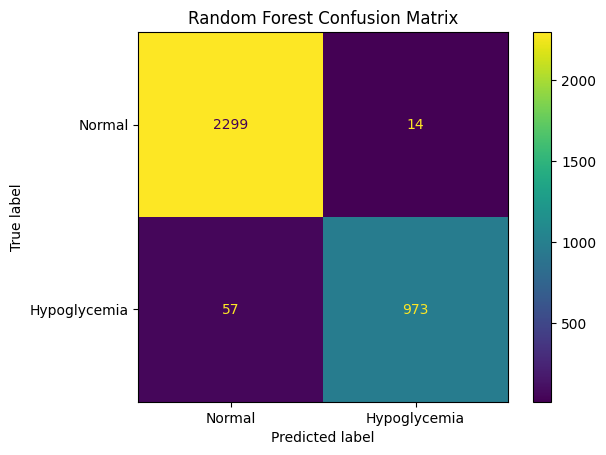

In [18]:
# Cell 13: Confusion matrix for Random Forest model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Hypoglycemia"]
)

disp.plot(values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

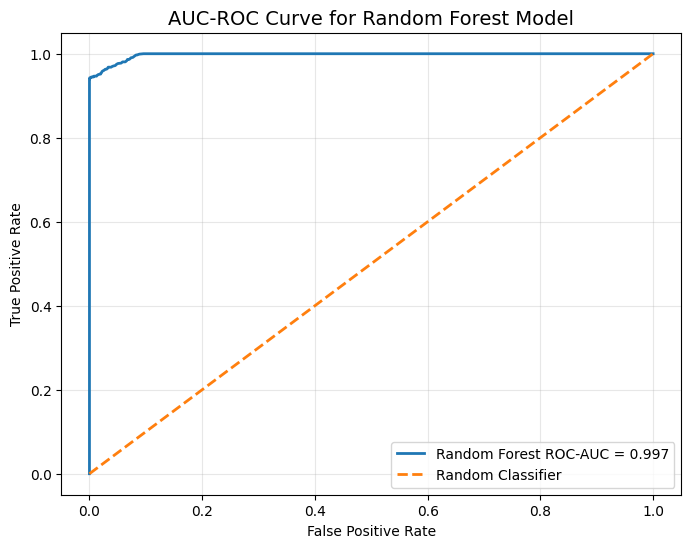

Random Forest ROC-AUC Score: 0.9974


In [24]:
# Cell 14: AUC-ROC Curve for Random Forest Model

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate False Positive Rate, True Positive Rate and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC value
roc_auc_value = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Random Forest ROC-AUC = {roc_auc_value:.3f}"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("AUC-ROC Curve for Random Forest Model", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.show()

print("Random Forest ROC-AUC Score:", round(roc_auc_value, 4))